## This notebook is a feasibility-test of the link budget computations of the balloon-sat project with considerations for base-station size and antenna placement on the balloon.

### 1.0 Free Space Path Loss

for RF in free space, the equation that determines path loss for a link is defined below.

$$PL \text{ (dB)} = 32.45 + 20 \log_{10}(f_{\text{MHz}}) + 20 \log_{10}(d_{\text{km}})$$

Where:
- $PL$ = Path Loss (dB)
- $f_{\text{MHz}}$ = Frequency (MHz)
- $d_{\text{km}}$ = Distance (km)

### 1.1 Path Loss with balloon altitude

Using the Free Space Path Loss Equation defined above, we can graph the change in path loss at a moderate distance to simulate launch rise conditions and also the final point- the high altitude float path loss.


Path loss at 15 km altitude:

145 MHz (2m)         99.20 dB
435 MHz (70cm)       108.74 dB


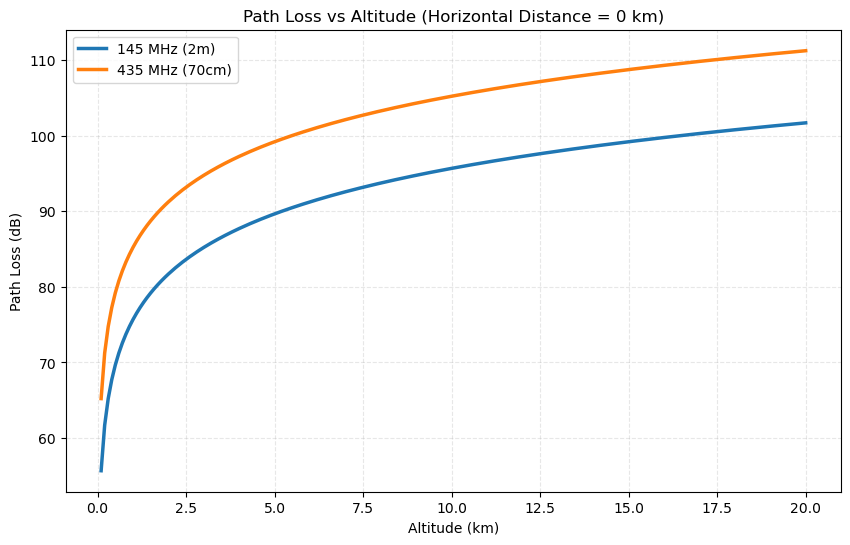

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Parameters
horizontal_distance_km = 0  # ground distance from you to balloon
altitude_km = np.linspace(0.1, 20, 200)  # avoid log(0)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, freq in frequencies.items():
    # Compute slant range
    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    
    # Compute path loss
    path_loss = calculate_path_loss(slant_range, freq)
    
    ax.plot(altitude_km, path_loss, linewidth=2.5, label=label)

ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Path Loss (dB)')
ax.set_title(f'Path Loss vs Altitude (Horizontal Distance = {horizontal_distance_km} km)')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

service_ceiling = 15
slant_15km = np.sqrt(horizontal_distance_km**2 + service_ceiling**2)

print("\nPath loss at 15 km altitude:\n")
for label, freq in frequencies.items():
    loss = calculate_path_loss(slant_15km, freq)
    print(f"{label:20} {loss:.2f} dB")

plt.show()

When holding distance to the balloon constant and assuming perfectly vertical ascent, we see a relationship with both the 2m and 70cm ham radio bands of a very large exponential increase through the initial climb of the path loss with a roughly 35 db increase in path loss throughout the climb up to 20km, which is roughly the service ceiling of a pico balloon class payload.

The link budget should be computed reguarding the service ceiling with the consideration that the balloon during the climb should be not only much easier to hear but also much easier to command with a lower-power base station.


### 1.2 balloon visibility distance

An important note for the balloon is the changing distance covered by the balloon in relation to its altitude, so below it is calculated to estimate a maximum mutual visibility circle covered by the satellite. This will also be used for computing the link budget later to see the maximum distance the balloon could be seen and utilized, and what the distance increase could mean for a stations requirements to utilize the balloon.

#### We model Earth as a sphere with radius \( R_E \), and the satellite at altitude \( h \).

#### Horizon condition

At the horizon point, the line of sight is tangent to Earth:

$$
\cos(\theta) = \frac{R_E}{R_E + h}
$$

Where:

- $\theta$ = central angle from sub-satellite point (radians)

---

#### Ground distance (great-circle arc length)

$$
d = R_E \cdot \theta
$$

Substituting:

$$
d = R_E \cdot \cos^{-1}\left(\frac{R_E}{R_E + h}\right)
$$

---

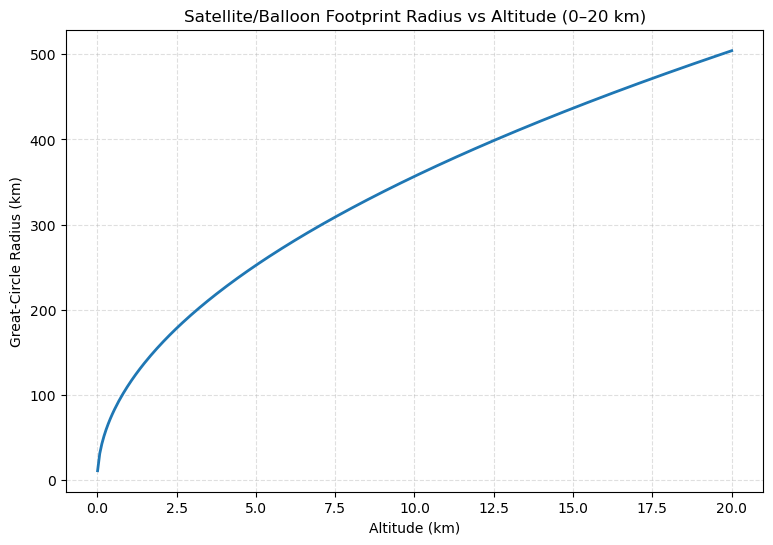

Great-circle footprint at 15 km altitude:

d ≈ 436.76 km


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Earth radius (km)
R_E = 6371.0

# Altitude range (km)
altitude_km = np.linspace(0.01, 20, 300)

# Great-circle footprint radius
def footprint_radius(h):
    theta = np.arccos(R_E / (R_E + h))
    return R_E * theta

radius_km = footprint_radius(altitude_km)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(altitude_km, radius_km, linewidth=2)

ax.set_xlabel("Altitude (km)")
ax.set_ylabel("Great-Circle Radius (km)")
ax.set_title("Satellite/Balloon Footprint Radius vs Altitude (0–20 km)")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

# --- 15 km calculation (no plot marker) ---
h_15 = 15
r_15 = footprint_radius(h_15)

print("Great-circle footprint at 15 km altitude:\n")
print(f"d ≈ {r_15:.2f} km")

With this we can see that roughly the maximum range for a station to get into the balloon will be 436km. This provides an important maximum for a "command distance" as any further and the balloon will be below the horizon and the link margin increases because of absorbtion beyond the horizon. With this radius we can also estimate the maximum distance between two stations using the balloon as a mutual hop would be double this, the greatcircle diameter, which is roughly 880 Km.

### 1.3 Path Loss with balloon horizontal distance


=== Values at 250 km ground distance ===

145 MHz (2m)
  Path Loss @250 km: 123.65 dB
  dPL/dx @250 km:     0.0346 dB/km

435 MHz (70cm)
  Path Loss @250 km: 133.19 dB
  dPL/dx @250 km:     0.0346 dB/km



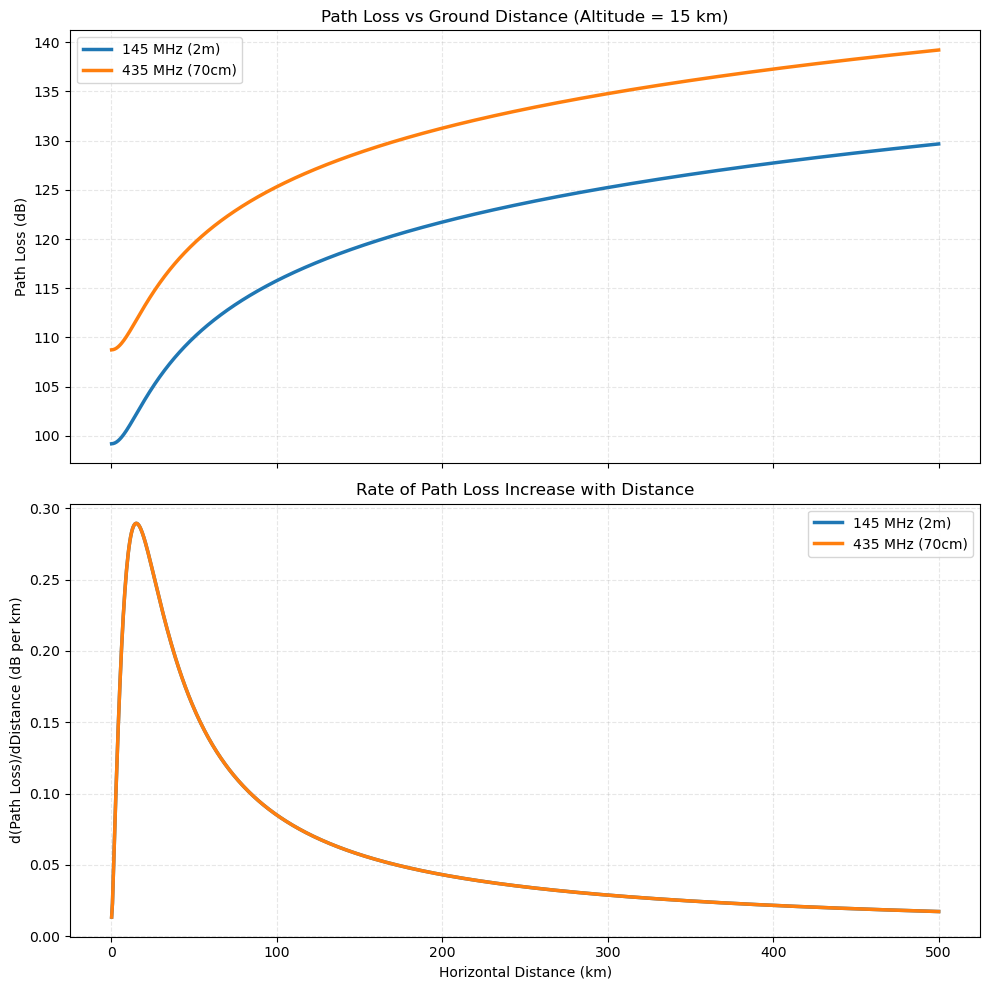

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Parameters
altitude_km = 15
horizontal_distance_km = np.linspace(0.1, 500, 1000)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for label, freq in frequencies.items():
    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    path_loss = calculate_path_loss(slant_range, freq)

    # --- Main plot ---
    ax1.plot(horizontal_distance_km, path_loss, linewidth=2.5, label=label)

    # --- Numerical derivative ---
    dPL_dx = np.gradient(path_loss, horizontal_distance_km)
    ax2.plot(horizontal_distance_km, dPL_dx, linewidth=2.5, label=label)

# Styling main plot
ax1.set_ylabel("Path Loss (dB)")
ax1.set_title(f"Path Loss vs Ground Distance (Altitude = {altitude_km} km)")
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.legend()

# Styling derivative plot
ax2.set_xlabel("Horizontal Distance (km)")
ax2.set_ylabel("d(Path Loss)/dDistance (dB per km)")
ax2.set_title("Rate of Path Loss Increase with Distance")
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend()

# --- Sample point ---
test_distance = 250  # km
h = 0.5  # small step for numerical derivative (km)

slant_test = np.sqrt(test_distance**2 + altitude_km**2)

print(f"\n=== Values at {test_distance} km ground distance ===\n")

for label, freq in frequencies.items():
    # Path loss at point
    pl = calculate_path_loss(slant_test, freq)

    # Finite difference derivative (local slope)
    d1 = np.sqrt((test_distance + h)**2 + altitude_km**2)
    d2 = np.sqrt((test_distance - h)**2 + altitude_km**2)

    pl1 = calculate_path_loss(d1, freq)
    pl2 = calculate_path_loss(d2, freq)

    dpl_dx = (pl1 - pl2) / (2 * h)

    print(f"{label}")
    print(f"  Path Loss @250 km: {pl:.2f} dB")
    print(f"  dPL/dx @250 km:     {dpl_dx:.4f} dB/km\n")
    
plt.tight_layout()
plt.show()

It is also important to note that the pico-balloon class of payload weight and balloon size have velocities at 15km of 100-270Km/Hr, which then becomes an estimate of 1.6-4.5 km/minute. This then would become a change in roughly 0.05536-0.1557db/minute at 250km of horizontal distance, which is far under an S unit a minute, and a change of 3.46-9.42db/Hr which would mean that over the course of an hour the link would significantly change, and this is worth noting for later mission objectives such a crossband repeater onboard and how long it should be active. This change would represent roughly the change from halfway out of the great circle to either the edge or directly overhead.

### 2.0 Transciever Requirements

We can break up the link budget portion of the station requirements to utilize the balloon into two segments, the Uplink and the Downlink.

The Uplink we will consider transmitter power, station antenna, recieving antenna on the balloon and the recieving performance of the planned DRA818.

The Downlink we will consider the DRA818's transmit power with both potential bands and antennas, and then recieving performance of an average FM transciever with an average recieving antenna.

### 2.1 Uplink Requirements

For the Uplink, a few parameters we will be using:

#### Transmitter Power : 37dBm (5W) - Average HT
#### Transmit Antenna  : 0 dBi - Quarter Wave Whip antenna

#### Recieving Antenna : ~ 0 dBi Quarter Wave Whip on Balloon for 2m
#### Recieving Antenna : ~ 2.5 dBi Dipole on Balloon on 70cm
#### DRA818 Recieving Performance : ~ -120dbm noise floor

#### Path Loss
We will be using the estimate of 250km of horizontal distance and 15km of vertical altitude to assume the most average station location case in reference to the balloon

2m Path Loss : 123.64dB

70cm Path Loss : 133.1dB

#### Mode-Specific SNR Requirements
These estimates are rough based on links for satellites for SNR needed for a positive packet decode and a good signal for FM voice.

FM Voice : 15dB SNR for readable voice

1200 Baud APRS Packet Deocde : 10dB SNR for consistency in decoding

## RF Link Budget (dB Formulation)

The received power is computed as the sum of all gains minus all losses:

$$
P_{rx} = P_{tx} + G_{tx} + G_{rx} - L_{total}
$$

---

## Total Loss Expansion

Total loss can be written as a sum of individual loss terms:

$$
L_{total} = L_{fs} + \sum L_{system}
$$

Where:

$$
\sum L_{system} = L_{cable} + L_{connector} + L_{polarization} + L_{pointing} + L_{fade} + \cdots
$$

---


## Full Expanded Link Budget

Substituting all terms:

$$
P_{rx} =
P_{tx}
+ G_{tx}
+ G_{rx}
- \left[
32.45 + 20 \log_{10}(f)
+ 20 \log_{10}(d)
+ \sum L_{system}
\right]
$$

---

## Noise and SNR

Noise floor:

$$
N = -174 + 10 \log_{10}(B) + NF
$$

Signal-to-noise ratio:

$$
SNR = P_{rx} - N
$$

---

## Decode Condition

A link is usable if:

$$
SNR \ge SNR_{threshold}
$$

### 2.2 Downlink Requirements

For the Uplink, a few parameters we will be using:

#### Transmitter Power : 27 dBm (0.5W) - DRA818
#### Transmit Antenna  : 0 dBi - Quarter Wave Whip antenna on Balloon for 2m
#### Transmit Antenna  : 2.5 dBi Dipole on Balloon for 70cm

#### Average Radio Recieving Performance : ~ -120dBm noise floor
#### Recieving Antenna : 0dBi Quarter Wave Whip Antenna

#### Path Loss
We will be using the estimate of 250km of horizontal distance and 15km of vertical altitude to assume the most average station location case in reference to the balloon

2m Path Loss : 123.64 dB

70cm Path Loss : 133.1 dB

#### Mode-Specific SNR Requirements
These estimates are rough based on links for satellites for SNR needed for a positive packet decode and a good signal for FM voice.

FM Voice : 15dB SNR for readable voice

1200 Baud APRS Packet Deocde : 10dB SNR for consistency in decoding